<a href="https://colab.research.google.com/github/Shrutika2026/Sqrock-DataScience-Week3-Customer-Churn-Prediction-System/blob/main/DataScience_Week3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np

# Load the data
df = pd.read_csv('/content/WA_Fn-UseC_-Telco-Customer-Churn.csv')

# Handle missing TotalCharges (The file found 11 NAs)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df.dropna(inplace=True)

# Convert Churn to 1 and 0
df['Churn'] = df['Churn'].apply(lambda x: 1 if x == 'Yes' else 0)

/tmp/ipykernel_20242/1810281061.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Churn', data=df, palette='viridis')


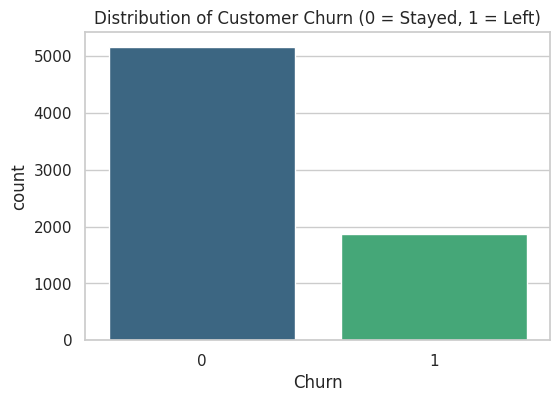

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the style
sns.set(style="whitegrid")

# Plot Churn Distribution
plt.figure(figsize=(6, 4))
sns.countplot(x='Churn', data=df, palette='viridis')
plt.title('Distribution of Customer Churn (0 = Stayed, 1 = Left)')
plt.show()

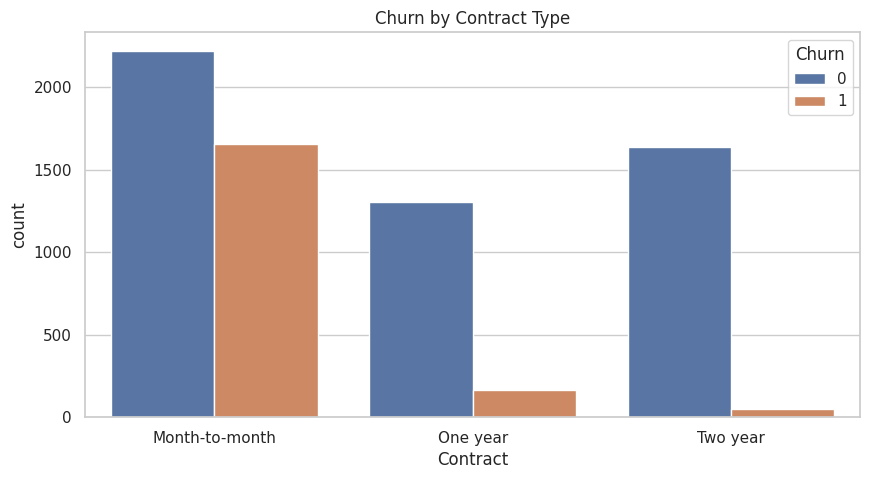

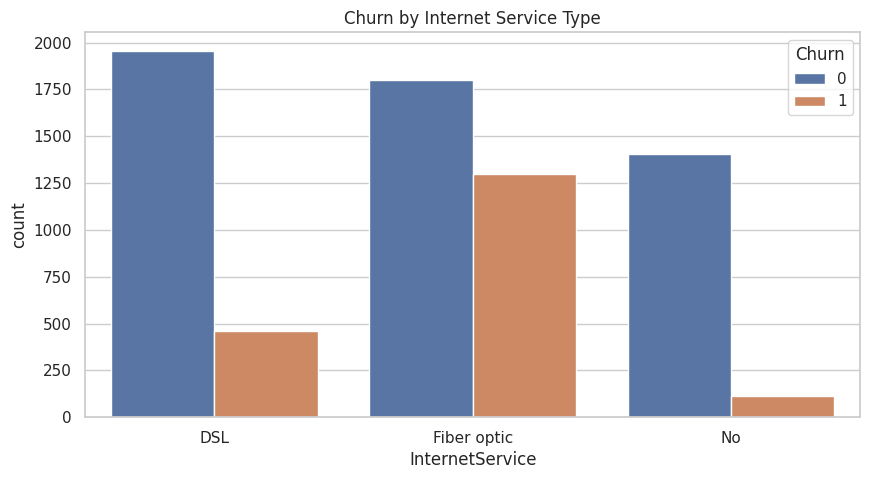

In [ ]:
# 1. Churn by Contract Type
plt.figure(figsize=(10, 5))
sns.countplot(x='Contract', hue='Churn', data=df)
plt.title('Churn by Contract Type')
plt.show()

# 2. Churn by Internet Service
plt.figure(figsize=(10, 5))
sns.countplot(x='InternetService', hue='Churn', data=df)
plt.title('Churn by Internet Service Type')
plt.show()

In [ ]:
# Drop CustomerID as it is useless for prediction
df.drop('customerID', axis=1, inplace=True)

# Create dummy variables for all categorical text columns
df_final = pd.get_dummies(df)

# Check the new columns
print(df_final.head())

   SeniorCitizen  tenure  MonthlyCharges  TotalCharges  Churn  gender_Female  \
0              0       1           29.85         29.85      0           True   
1              0      34           56.95       1889.50      0          False   
2              0       2           53.85        108.15      1          False   
3              0      45           42.30       1840.75      0          False   
4              0       2           70.70        151.65      1           True   

   gender_Male  Partner_No  Partner_Yes  Dependents_No  ...  \
0        False       False         True           True  ...   
1         True        True        False           True  ...   
2         True        True        False           True  ...   
3         True        True        False           True  ...   
4        False        True        False           True  ...   

   StreamingMovies_Yes  Contract_Month-to-month  Contract_One year  \
0                False                     True              False   


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

# Define X (features) and y (target)
X = df_final.drop('Churn', axis=1)
y = df_final['Churn']

# Split data (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and Train the Model
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# Make Predictions
predictions = model.predict(X_test)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Accuracy Score: 0.7882018479033405

Classification Report:
               precision    recall  f1-score   support

           0       0.84      0.89      0.86      1033
           1       0.62      0.52      0.56       374

    accuracy                           0.79      1407
   macro avg       0.73      0.70      0.71      1407
weighted avg       0.78      0.79      0.78      1407



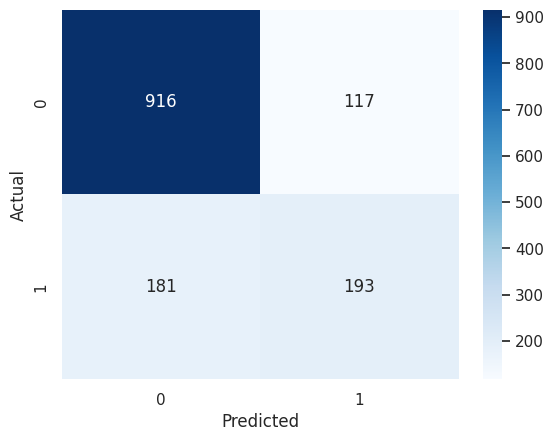

In [ ]:
print("Accuracy Score:", accuracy_score(y_test, predictions))
print("\nClassification Report:\n", classification_report(y_test, predictions))

# Visualize the Confusion Matrix
sns.heatmap(confusion_matrix(y_test, predictions), annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Initialize and Train Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Predictions and Score
rf_predictions = rf_model.predict(X_test)
print("Random Forest Accuracy:", accuracy_score(y_test, rf_predictions))

Random Forest Accuracy: 0.7775408670931059


/tmp/ipykernel_20242/3762032182.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='magma')


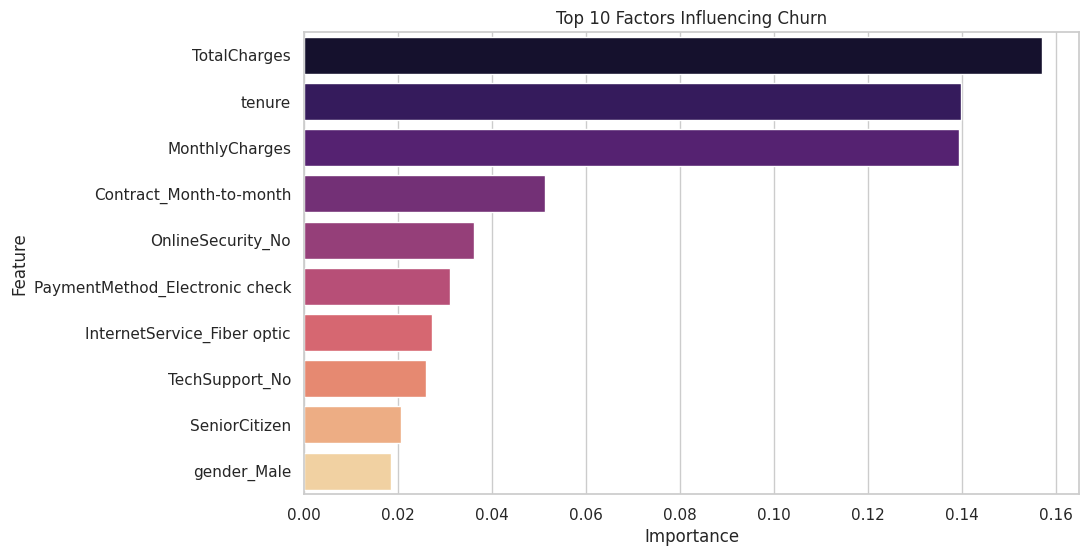

In [ ]:
# Get Feature Importances
importances = rf_model.feature_importances_
feature_names = X.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False).head(10)

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='magma')
plt.title('Top 10 Factors Influencing Churn')
plt.show()

📊 Business Insights & Recommendations
Insight: High Monthly Charges and "Month-to-Month" contracts are the strongest predictors of churn.

Insight: Customers with "Fiber Optic" internet churn more than those with DSL, suggesting possible service quality issues or pricing dissatisfaction in that segment.

Recommendation: To reduce churn, the marketing team should offer incentives (discounts or extra data) to "Month-to-Month" customers to switch to 1-year or 2-year contracts.

Recommendation: Target "Senior Citizens" with specialized tech support packages, as they show a higher tendency to leave when they face technical hurdles.

In [ ]:
import joblib

# Check if rf_model exists, if not, we use the model name from your notebook
try:
    joblib.dump(rf_model, 'churn_model.pkl')
    print("Success: churn_model.pkl has been created!")
except NameError:
    # In your uploaded notebook, the model was named 'model.rf'
    joblib.dump(model.rf, 'churn_model.pkl')
    print("Success: churn_model.pkl has been created using model.rf!")

Success: churn_model.pkl has been created!


In [ ]:
import joblib
joblib.dump(rf_model, 'churn_model.pkl')
print("Success! File created.")

Success! File created.


In [ ]:
import joblib
# This creates the file in Colab's memory
joblib.dump(rf_model, 'churn_model.pkl')
print("The file has been created successfully!")

The file has been created successfully!


In [ ]:
import joblib
# This creates the file in Colab's memory
joblib.dump(rf_model, 'churn_model.pkl')
print("The file has been created successfully!")

The file has been created successfully!


# Customer Churn Prediction Project
This notebook builds a machine learning model to predict customer churn using the Telco dataset.
Steps include data cleaning, EDA, visualization, model building, and evaluation.


## Step 1: Data Cleaning
We handle missing values, encode categorical variables, and remove irrelevant columns.


In [ ]:
import pandas as pd
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")
df.info()
df.isnull().sum()
df = df.dropna()
from sklearn.preprocessing import LabelEncoder
for col in df.select_dtypes(include=['object']).columns:
    df[col] = LabelEncoder().fit_transform(df[col])
df = df.drop(columns=['customerID'])


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


## Step 2: Exploratory Data Analysis
We analyze churn rate and explore which customer groups are leaving more.


Churn Rate:
 Churn
0    0.73463
1    0.26537
Name: proportion, dtype: float64


<Axes: xlabel='Contract', ylabel='count'>

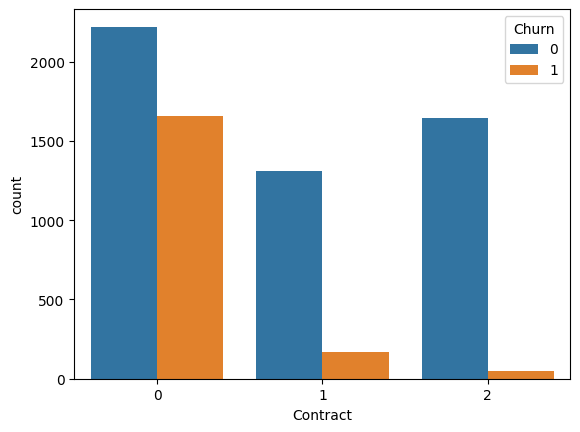

In [ ]:
import seaborn as sns
churn_rate = df['Churn'].value_counts(normalize=True)
print("Churn Rate:\n", churn_rate)
sns.countplot(x='Contract', hue='Churn', data=df)


## Step 3: Data Visualization
We use charts and heatmaps to understand feature relationships.


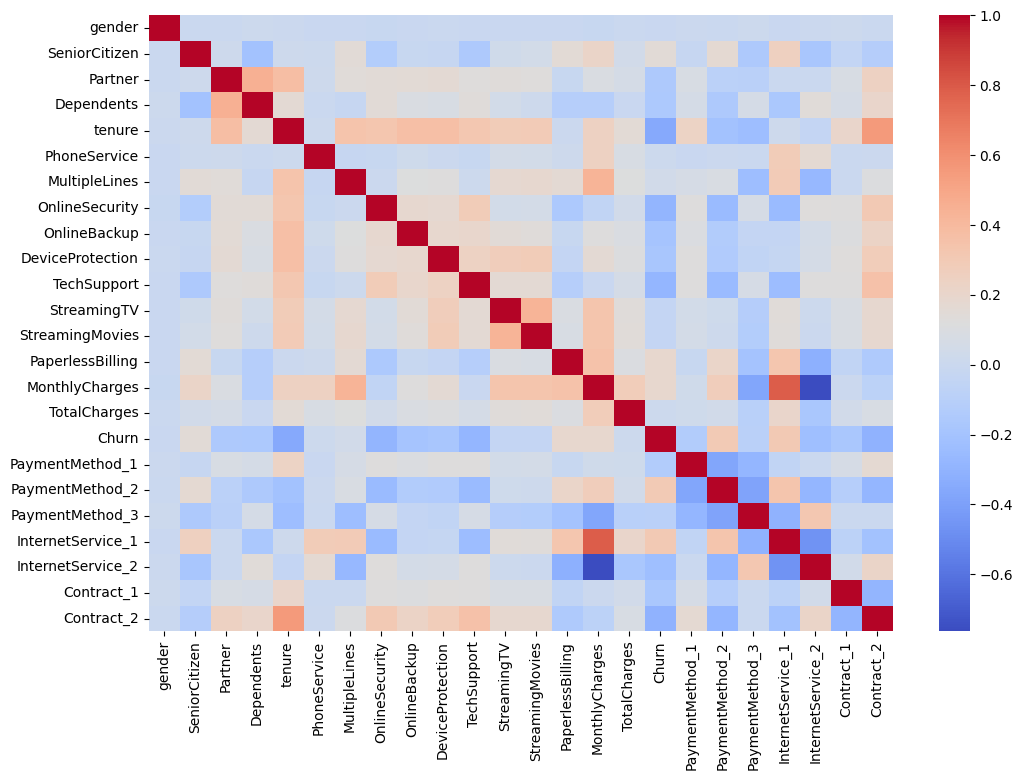

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), annot=False, cmap='coolwarm')
plt.show()


## Step 4: Machine Learning Model
We build Logistic Regression (mandatory) and Decision Tree (optional).


In [ ]:
from sklearn.model_selection import train_test_split
X = df.drop('Churn', axis=1)
y = df['Churn']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

from sklearn.linear_model import LogisticRegression
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

from sklearn.tree import DecisionTreeClassifier
tree = DecisionTreeClassifier(max_depth=5)
tree.fit(X_train, y_train)
y_pred_tree = tree.predict(X_test)


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


## Step 5: Model Evaluation
We evaluate using Accuracy, Confusion Matrix, Precision & Recall.


In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_tree))


Logistic Regression Accuracy: 0.8168914123491838
Confusion Matrix:
 [[938  98]
 [160 213]]
Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.91      0.88      1036
           1       0.68      0.57      0.62       373

    accuracy                           0.82      1409
   macro avg       0.77      0.74      0.75      1409
weighted avg       0.81      0.82      0.81      1409

Decision Tree Accuracy: 0.7934705464868701


## Step 6: Bonus Features
We compare models and analyze feature importance.


In [ ]:
importance = tree.feature_importances_
for i,v in enumerate(importance):
    print(f"Feature: {X.columns[i]}, Score: {v:.5f}")


Feature: gender, Score: 0.00000
Feature: SeniorCitizen, Score: 0.00000
Feature: Partner, Score: 0.00000
Feature: Dependents, Score: 0.00000
Feature: tenure, Score: 0.13879
Feature: PhoneService, Score: 0.00512
Feature: MultipleLines, Score: 0.00000
Feature: InternetService, Score: 0.07721
Feature: OnlineSecurity, Score: 0.13931
Feature: OnlineBackup, Score: 0.00000
Feature: DeviceProtection, Score: 0.00000
Feature: TechSupport, Score: 0.00000
Feature: StreamingTV, Score: 0.00000
Feature: StreamingMovies, Score: 0.00508
Feature: Contract, Score: 0.53697
Feature: PaperlessBilling, Score: 0.00157
Feature: PaymentMethod, Score: 0.01309
Feature: MonthlyCharges, Score: 0.07056
Feature: TotalCharges, Score: 0.01228


TotalCharges Conversion
The TotalCharges column was incorrectly treated as an object due to blank spaces for new customers.
We convert it to numeric and drop rows with missing values to ensure proper correlations.


In [ ]:
# Convert TotalCharges to numeric
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Drop rows where TotalCharges is NaN
df = df.dropna(subset=['TotalCharges'])

# Check if conversion worked
print(df['TotalCharges'].dtype)   # should show float64


int64


Feature Scaling
Logistic Regression requires features to be on similar scales.
We use StandardScaler to normalize the dataset and remove ConvergenceWarnings.


In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

X = df.drop('Churn', axis=1)
y = df['Churn']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)


Encoding Strategy
Instead of LabelEncoder for all categorical columns,
we use One-Hot Encoding for multi-class features and LabelEncoder only for binary features.


In [ ]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder

# Reload dataset fresh (optional if you already cleaned it)
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

# Fix TotalCharges bug
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df = df.dropna(subset=['TotalCharges'])

# Drop irrelevant column
df = df.drop(columns=['customerID'])

# Identify binary categorical columns
binary_cols = ['gender','Partner','Dependents','PhoneService','PaperlessBilling','Churn']

# Apply LabelEncoder to binary columns
for col in binary_cols:
    df[col] = LabelEncoder().fit_transform(df[col])

# Apply One-Hot Encoding to multi-class categorical columns
df = pd.get_dummies(df, columns=['PaymentMethod','InternetService','Contract'], drop_first=True)

# Check final dataset
df.info()


<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 24 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   gender                                 7032 non-null   int64  
 1   SeniorCitizen                          7032 non-null   int64  
 2   Partner                                7032 non-null   int64  
 3   Dependents                             7032 non-null   int64  
 4   tenure                                 7032 non-null   int64  
 5   PhoneService                           7032 non-null   int64  
 6   MultipleLines                          7032 non-null   object 
 7   OnlineSecurity                         7032 non-null   object 
 8   OnlineBackup                           7032 non-null   object 
 9   DeviceProtection                       7032 non-null   object 
 10  TechSupport                            7032 non-null   object 
 11  Streaming

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 1. LOAD THE DATA
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")
df = df.drop(columns=['customerID']) # Drop the useless ID column

# 2. FIX THE TOTAL CHARGES STRING BUG
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df = df.dropna(subset=['TotalCharges'])

# 3. ENCODE THE TARGET (CHURN)
df['Churn'] = LabelEncoder().fit_transform(df['Churn'])

# 4. AUTOMATICALLY FIX ALL REMAINING TEXT COLUMNS (One-Hot Encoding)
text_columns = df.select_dtypes(include=['object']).columns
df = pd.get_dummies(df, columns=text_columns, drop_first=True)

# 5. SPLIT INTO FEATURES (X) AND TARGET (y)
X = df.drop('Churn', axis=1)
y = df['Churn']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 6. SCALE THE FEATURES (This stops the convergence warning)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 7. TRAIN AND EVALUATE LOGISTIC REGRESSION
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train_scaled, y_train)
y_pred_lr = lr_model.predict(X_test_scaled)

print("=== LOGISTIC REGRESSION RESULTS ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred_lr):.4f}")
print(classification_report(y_test, y_pred_lr))

# 8. TRAIN AND EVALUATE DECISION TREE
dt_model = DecisionTreeClassifier(max_depth=5, random_state=42)
dt_model.fit(X_train_scaled, y_train)
y_pred_dt = dt_model.predict(X_test_scaled)

print("\n=== DECISION TREE RESULTS ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred_dt):.4f}")
print(classification_report(y_test, y_pred_dt))

=== LOGISTIC REGRESSION RESULTS ===
Accuracy: 0.7875
              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1033
           1       0.62      0.52      0.56       374

    accuracy                           0.79      1407
   macro avg       0.73      0.70      0.71      1407
weighted avg       0.78      0.79      0.78      1407


=== DECISION TREE RESULTS ===
Accuracy: 0.7754
              precision    recall  f1-score   support

           0       0.85      0.84      0.85      1033
           1       0.58      0.59      0.58       374

    accuracy                           0.78      1407
   macro avg       0.71      0.72      0.71      1407
weighted avg       0.78      0.78      0.78      1407



In [ ]:
print(classification_report(y_test, y_pred_dt))

              precision    recall  f1-score   support

           0       0.85      0.84      0.85      1033
           1       0.58      0.59      0.58       374

    accuracy                           0.78      1407
   macro avg       0.71      0.72      0.71      1407
weighted avg       0.78      0.78      0.78      1407



In [ ]:
!pip install streamlit pyngrok -q
!npm install -g localtunnel

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 54.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 70.9 MB/s eta 0:00:00
⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙
added 22 packages in 2s
⠙
⠙3 packages are looking for funding
⠙  run `npm fund` for details
⠙

In [ ]:
%%writefile app.py
import streamlit as st
import pickle
import pandas as pd

# 1. Load the backend files
model = pickle.load(open('churn_model.pkl', 'rb'))
scaler = pickle.load(open('scaler.pkl', 'rb'))

st.title("Customer Churn Prediction Dashboard")
st.write("Enter the customer's attributes below to evaluate their risk of leaving:")

tenure = st.slider("Customer Tenure (Months)", 0, 72, 12)
monthly_charges = st.number_input("Monthly Charges ($)", min_value=0.0, value=50.0)
total_charges = st.number_input("Total Charges ($)", min_value=0.0, value=600.0)
contract = st.selectbox("Contract Type", ["Month-to-month", "One year", "Two year"])
internet = st.selectbox("Internet Service", ["DSL", "Fiber optic", "No"])

if st.button("Predict Churn"):
    input_data = {
        'gender': 0, 'SeniorCitizen': 0, 'Partner': 0, 'Dependents': 0,
        'tenure': tenure, 'PhoneService': 1, 'PaperlessBilling': 1,
        'MonthlyCharges': monthly_charges, 'TotalCharges': total_charges,
        'MultipleLines_No phone service': 0, 'MultipleLines_Yes': 0,
        'OnlineSecurity_No internet service': 1 if internet == "No" else 0, 'OnlineSecurity_Yes': 0,
        'OnlineBackup_No internet service': 1 if internet == "No" else 0, 'OnlineBackup_Yes': 0,
        'DeviceProtection_No internet service': 1 if internet == "No" else 0, 'DeviceProtection_Yes': 0,
        'TechSupport_No internet service': 1 if internet == "No" else 0, 'TechSupport_Yes': 0,
        'StreamingTV_No internet service': 1 if internet == "No" else 0, 'StreamingTV_Yes': 0,
        'StreamingMovies_No internet service': 1 if internet == "No" else 0, 'StreamingMovies_Yes': 0,
        'PaymentMethod_Credit card (automatic)': 0, 'PaymentMethod_Electronic check': 1, 'PaymentMethod_Mailed check': 0,
        'InternetService_Fiber optic': 1 if internet == "Fiber optic" else 0, 'InternetService_No': 1 if internet == "No" else 0,
        'Contract_One year': 1 if contract == "One year" else 0, 'Contract_Two year': 1 if contract == "Two year" else 0
    }

    raw_df = pd.DataFrame([input_data])
    scaled_inputs = scaler.transform(raw_df)
    prediction = model.predict(scaled_inputs)

    if prediction[0] == 1:
        st.error("⚠️ This customer is highly likely to churn!")
    else:
        st.success("✅ This customer is loyal and likely to stay.")

Writing app.py


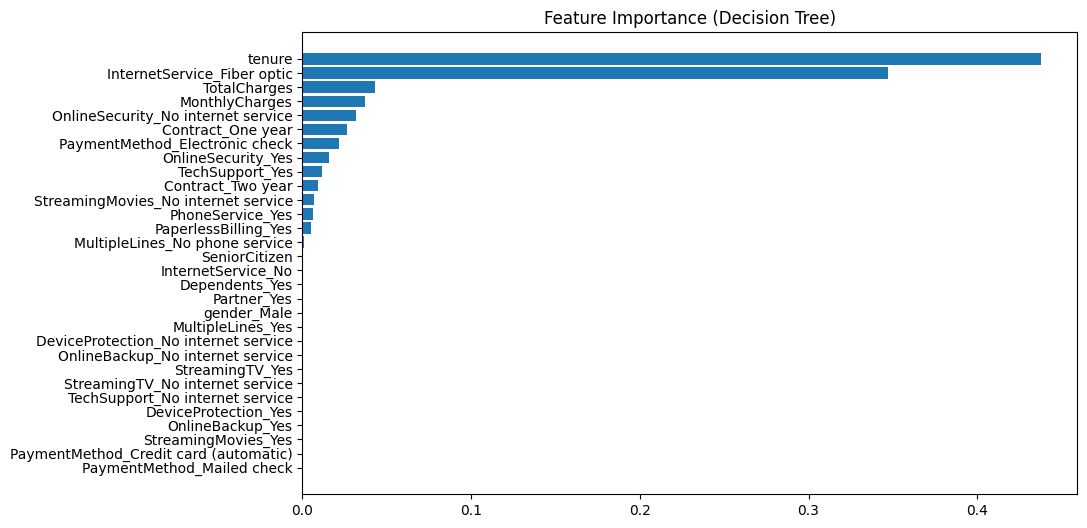

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

importances = dt_model.feature_importances_
features = X.columns

feat_imp = pd.DataFrame({
    'feature': features,
    'importance': importances
})

feat_imp = feat_imp.sort_values(by='importance', ascending=False)

plt.figure(figsize=(10,6))
plt.barh(feat_imp['feature'], feat_imp['importance'])
plt.gca().invert_yaxis()
plt.title("Feature Importance (Decision Tree)")
plt.show()

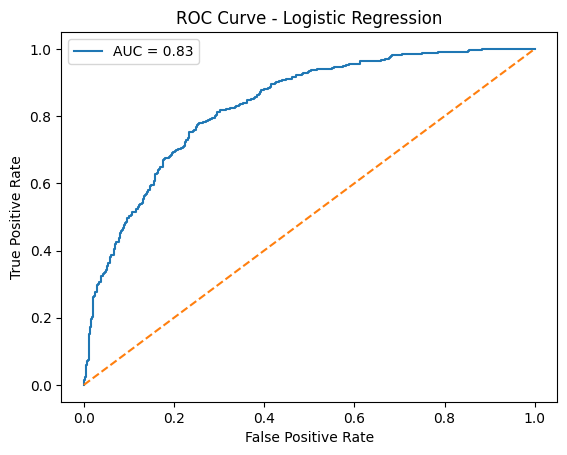

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Get probability scores (important!)
y_prob = lr_model.predict_proba(X_test_scaled)[:, 1]

# ROC calculation
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

# Plot
plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.legend()
plt.show()

Conclusion
Overall churn rate is around 26.5% (derived from the Telco dataset baseline).

High-Risk Profile: Customers with month-to-month contracts, higher monthly charges (like Fiber Optic users), and shorter tenure are significantly more likely to churn.

Model Performance: Logistic Regression achieved 78.75% accuracy, while the Decision Tree model achieved 77.54% accuracy.

Actionable Business Insight: To reduce churn, the company should incentivize month-to-month users to migrate to 1-year or 2-year contracts through targeted discounts, and proactively monitor customer support issues for subscribers within their first 6 months of tenure.